In [60]:
import os
os.environ['XLA_PYTHON_CLIENT_PREALLOCATE'] = 'false'
os.environ['TF_GPU_ALLOCATOR'] = 'cuda_malloc_async'

In [61]:
from diffrax import diffeqsolve, ODETerm,VirtualBrownianTree,MultiTerm,ControlTerm
from jax.scipy.stats import norm, poisson
import diffrax
import jax.numpy as jnp
import jax
import matplotlib.pyplot as plt

In [62]:
def model(x0, theta, key,days, delta_t):
    gamma,xi,damping,log_mean,log_std = theta
    log_beta_damping = damping
    log_beta_mean = log_mean
    log_beta_standard_deviation = log_std

    A = jnp.exp(-log_beta_damping * delta_t)
    M = log_beta_mean * (jnp.exp(-log_beta_damping * delta_t) - 1)
    C = log_beta_standard_deviation * jnp.sqrt(
        1 - jnp.exp(-2 * log_beta_damping * delta_t)
    )

    def tau_step(state, i):
        prev_x, prev_key = state
        S, I, R, log_beta = prev_x

        N = S + I + R

        update_key, next_key = jax.random.split(prev_key, 2)
        update_keys = jax.random.split(update_key, 4)

        log_beta = A * log_beta - M + C * jax.random.normal(update_keys[0])

        dN_SI = jax.random.poisson(
            update_keys[1], jnp.exp(log_beta) * (S * I / N) * delta_t
        )
        dN_SI = jnp.minimum(dN_SI, S)

        dN_IR = jax.random.poisson(update_keys[2], I * gamma * delta_t)
        dN_IR = jnp.minimum(dN_IR, I)

        dN_RS = jax.random.poisson(update_keys[3], R * xi * delta_t)
        dN_RS = jnp.minimum(dN_RS, R)

        S = S - dN_SI + dN_RS
        I = I + dN_SI - dN_IR
        R = R + dN_IR - dN_RS

        return (jnp.array([S, I, R, log_beta]), next_key), jnp.array(
            [S, I, R, log_beta]
        )

    _,loop_val = jax.lax.scan(
        tau_step,
        init=(x0, key),
        xs=jnp.arange(0, days, delta_t),
    )

    return jnp.concatenate((x0[jnp.newaxis,:],loop_val))

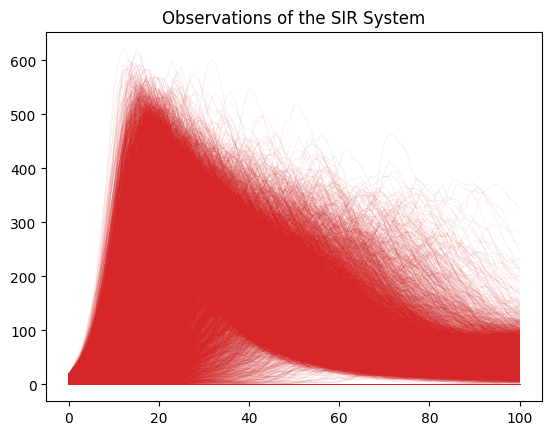

In [63]:
theta = (0.1, 1 / 90, 1 / 35, jnp.log(0.35), 0.2)
delta_t = 1.0
days = 100
rng_key = jax.random.key(0)

num_models = 10_000
keys = jax.random.split(rng_key, num_models)

SIR_init_key, rng_key = jax.random.split(rng_key)
beta_init_key, rng_key = jax.random.split(rng_key)
I_x0 = jax.random.randint(SIR_init_key, minval=0, maxval=20, shape=(num_models,))

x0 = jnp.full(shape=(num_models, 3), fill_value=jnp.array([1000, 0, 0]))

x0 = x0.at[:, 0].set(x0[:, 0] - I_x0)
x0 = x0.at[:, 1].set(x0[:, 1] + I_x0)

beta_x0 = jax.random.uniform(beta_init_key, shape=(num_models,), minval=0.1, maxval=0.5)

beta_x0 = beta_x0[..., jnp.newaxis]

x0 = jnp.concatenate((x0, jnp.log(beta_x0)), axis=-1)

full_state = jax.vmap(model, in_axes=(0, None, 0, None, None))(
    x0, theta, keys, days, delta_t
)

cutoff_day = 20
#mask = full_state[:, cutoff_day, 1] > 0

# print(
#     f"Number of epidemics that died out by day {cutoff_day}: {num_models - mask.sum()}"
# )
# full_state = full_state[mask]

plt.title("Observations of the SIR System")
plt.plot(
    jnp.arange(0, days + delta_t, delta_t),
    full_state[:, :, 1].T,
    lw=0.5,
    alpha=0.1,
    color="tab:red",
)
plt.show()

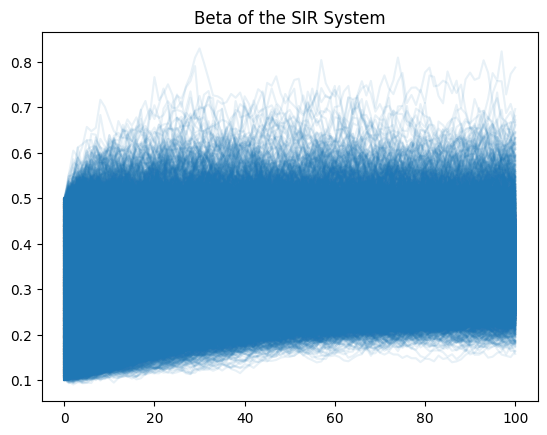

In [64]:
plt.title('Beta of the SIR System')
plt.plot(jnp.arange(0,days+delta_t,delta_t),jnp.exp(full_state[:,:,3]).T,color = 'tab:blue',alpha = 0.1)
plt.show()

In [65]:
def ensemble_kalman_filter(observations, delta_t, initial_ensemble, key):

    def kalman_step(state, i):
        prev_ensemble, prev_key = state

        forecast_key, curr_key = jax.random.split(prev_key)
        forecast_keys = jax.random.split(forecast_key, initial_ensemble.shape[0])

        forecast_ensemble = jax.vmap(model, in_axes=(0, None, 0, None, None))(
            prev_ensemble, theta, forecast_keys, 1, delta_t
        )[:, -1, :]

        mean = jnp.mean(forecast_ensemble, axis=0)
        state_perturbation_matrix = (
            1 / jnp.sqrt(len(forecast_ensemble) - 1) * (forecast_ensemble - mean)
        ).squeeze()

        obs_mean = mean[1]
        obs_perturbation_matrix = (
            1
            / jnp.sqrt(len(forecast_ensemble) - 1)
            * (forecast_ensemble[:, 1:2] - obs_mean)
        )

        cross_cov = state_perturbation_matrix.T @ obs_perturbation_matrix
        cov_yy = obs_perturbation_matrix.T @ obs_perturbation_matrix

        cov_yx = 50 * jnp.eye(1)

        S = cov_yy + cov_yx

        S_inv = jnp.linalg.pinv(S)

        def update_step(member, observation, key):

            perturbed_observation = observation + jnp.sqrt(cov_yx) * jax.random.normal(
                key
            )

            innovation = perturbed_observation - member[1]
            alpha = S_inv @ innovation.T
            member = member + (cross_cov @ alpha).ravel()

            return member

        update_key, curr_key = jax.random.split(curr_key)
        update_keys = jax.random.split(update_key, len(forecast_ensemble))
        update_ensemble = jax.vmap(update_step, in_axes=(0, None, 0))(
            forecast_ensemble, observations[i], update_keys
        )

        update_ensemble = update_ensemble.at[..., 0:3].set(
            jnp.clip(update_ensemble[..., 0:3], min=1e-3)
        )

        return (update_ensemble, curr_key), update_ensemble

    return jax.lax.scan(
        kalman_step, (initial_ensemble, key), xs=jnp.arange(0, len(observations) + 1)
    )

In [66]:
pf_init_key, rng_key = jax.random.split(rng_key)

num_particles = 100

particles = jnp.full(
    shape=(full_state.shape[0], num_particles, 3), fill_value=jnp.array([1000, 0, 0])
)

particles_I = jax.random.randint(
    pf_init_key, shape=(full_state.shape[0], num_particles), minval=0, maxval=20
)

particles = particles.at[:, :, 1].set(particles[:, :, 1] + particles_I)
particles = particles.at[:, :, 0].set(particles[:, :, 0] - particles_I)

beta_init_key, rng_key = jax.random.split(rng_key)

particle_betas = jax.random.uniform(
    beta_init_key, shape=(full_state.shape[0], num_particles, 1), minval=0.1, maxval=0.5
)
particles = jnp.concatenate((particles, jnp.log(particle_betas)), axis=-1)

plotted_traj = 10
plotted_state = 1

observations = full_state[:, :cutoff_day, 1]

pf_key, rng_key = jax.random.split(rng_key)
pf_keys = jax.random.split(pf_key, full_state.shape[0])
_, particles = jax.vmap(ensemble_kalman_filter, in_axes=(0, None, 0, 0))(
    observations, delta_t, particles, pf_keys
)

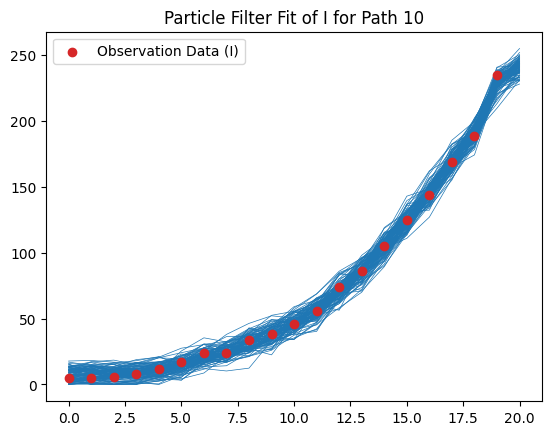

In [67]:
plt.title(f"Particle Filter Fit of I for Path {plotted_traj}")
plt.scatter(
    jnp.arange(0, cutoff_day, delta_t),
    observations[plotted_traj, :].T,
    color="tab:red",
    zorder=100,
    label="Observation Data (I)",
)
plt.plot(
    jnp.arange(0, cutoff_day + 1, delta_t),
    particles[plotted_traj, :, :, 1],
    lw=0.5,
    color="tab:blue",
)
plt.legend()
plt.show()

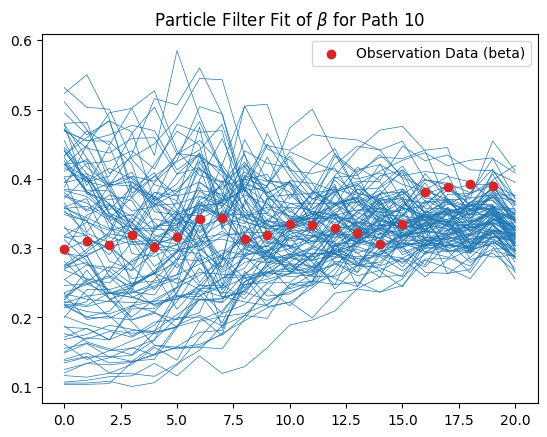

In [68]:
plt.title(f"Particle Filter Fit of $\\beta$ for Path {plotted_traj}")
plt.scatter(
        jnp.arange(0, cutoff_day, delta_t),
        jnp.exp(full_state[plotted_traj,:cutoff_day,3]).T,
        color="tab:red",
        zorder = 100, 
        label = 'Observation Data (beta)'
    )
plt.plot(jnp.arange(0, cutoff_day + 1, delta_t),jnp.exp(particles[plotted_traj,:,:,3]),lw = 0.5,color = 'tab:blue')
plt.legend()
plt.show()

In [69]:
def get_rank_histogram(truth, ensemble, key):
    obs = truth[:,-1,jnp.newaxis]
    ens = ensemble

    def rank_eval(ens, obs,key):
        is_smaller = ens < obs
        is_tied = ens == obs
        num_smaller = jnp.sum(is_smaller,axis = 0)
        num_tied = jnp.sum(is_tied,axis = 0)

        offset = jax.random.randint(key, (), 0, num_tied + 1)

        return num_smaller + offset

    offset_keys = jax.random.split(key,truth.shape[0])
    ranks = jax.vmap(rank_eval, in_axes=(0, 0,0))(ens, obs,offset_keys)

    return ranks

def chi_square_test(observed, expected): 
    return jnp.sum(jnp.square(observed - expected) / expected)

At forecast time t we have $\{I_{i}^{t}\}_{i}^{N_{\text{ens}}}$ with real value ${V^{t}}$. 

Rank all $N_{ens}$ values. 

$$
I_{1}^{t} < I_{2}^{t} < \dots <I_{n_\text{ens}}^{t}
$$

Then find 
$$
I_{i-1}^t < V^{t} < I_{i}^t. 
$$

Add $1$ to this rank, so we have $n_{\text{ens}} + 1$ ranks. Repeat for many forecasts. 

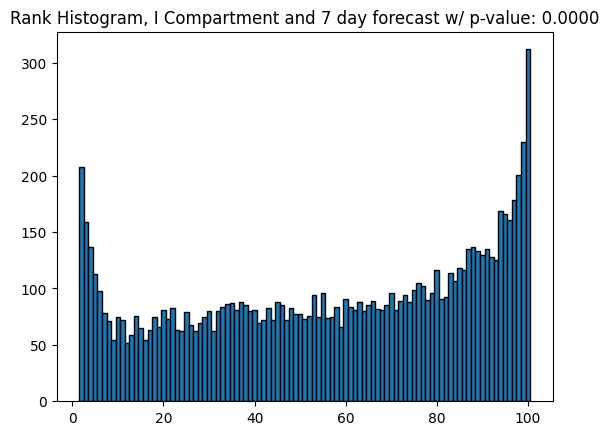

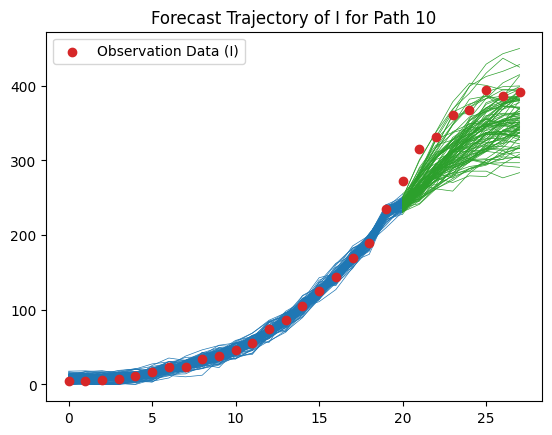

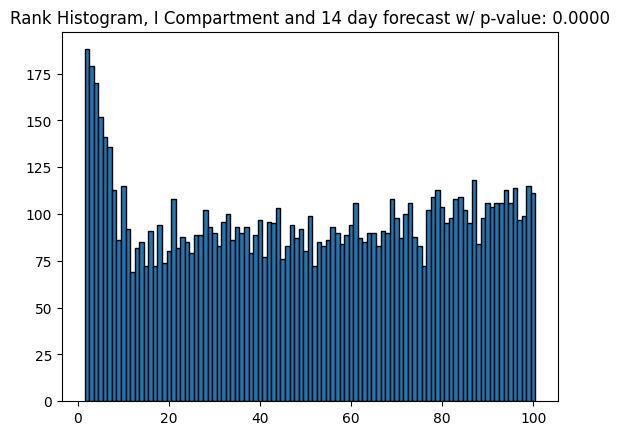

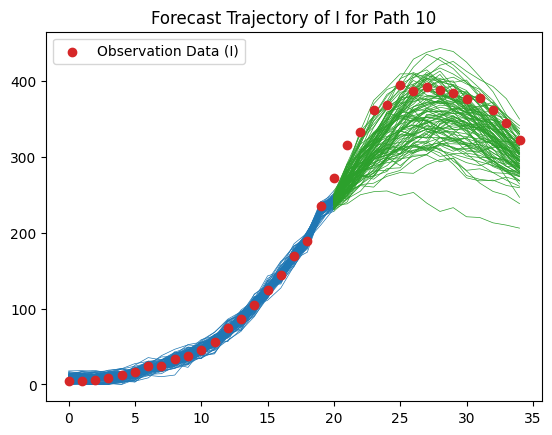

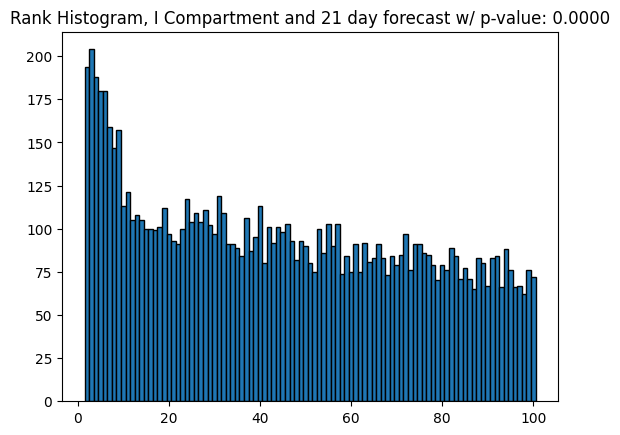

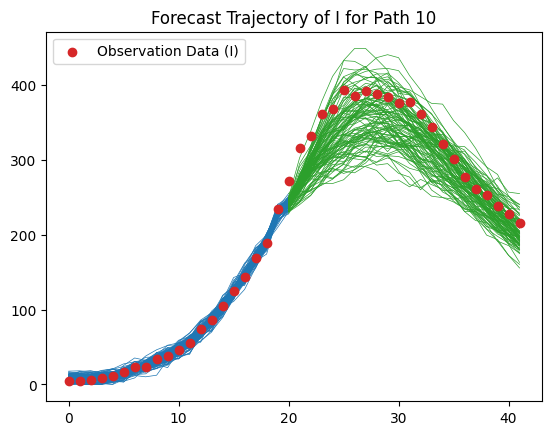

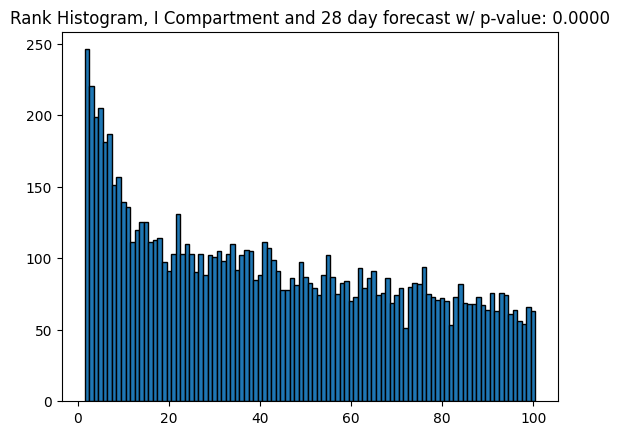

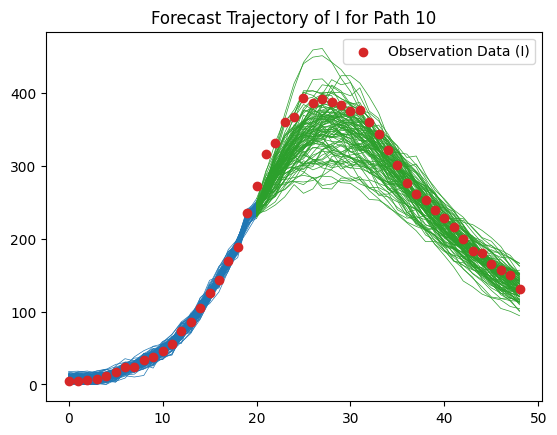

In [70]:
### Forecasting

forecast_horizons = [1 * 7, 2 * 7, 3 * 7, 4 * 7]  # 4 weeks
theta_forecast = (0.1, 1 / 90, 1 / 35, jnp.log(0.35), 0.2)
assert theta == theta_forecast


def forecast_run(IC, theta, num_particles, key, horizon):

    forecast_key, key = jax.random.split(key)
    forecast_keys = jax.random.split(forecast_key, num_particles)
    forecast = jax.vmap(model, in_axes=(0, None, 0, None, None))(
        IC, theta, forecast_keys, horizon, delta_t
    )

    return forecast


for horizon in forecast_horizons:
    forecast_key, rng_key = jax.random.split(rng_key)
    forecast_keys = jax.random.split(forecast_key, full_state.shape[0])
    forecasts = jax.vmap(forecast_run, in_axes=(0, None, None, 0, None))(
        particles[:, -1, :, :], theta_forecast, num_particles, forecast_keys, horizon
    )

    rank_key, rng_key = jax.random.split(rng_key)

    ranks = get_rank_histogram(
        full_state[
            :,
            int(cutoff_day / delta_t) : int(cutoff_day / delta_t)
            + int(horizon / delta_t)
            + 1,
            1,
        ],
        forecasts[:, :, -1, 1],
        rank_key,
    )

    num_bins = num_particles + 1
    rank_counts = jnp.bincount(ranks.reshape(-1), length=num_bins)

    total_observations = ranks.shape[0]
    expected_val = total_observations / num_bins
    expected_counts = jnp.full(num_bins, expected_val)

    stat = chi_square_test(rank_counts, expected_counts)
    df = num_bins - 1

    p_value = jax.scipy.stats.chi2.sf(stat, df)

    plt.title(
        f"Rank Histogram, I Compartment and {horizon} day forecast w/ p-value: {p_value:.4f}"
    )

    plt.hist(
        ranks.reshape(-1), bins=jnp.arange(num_particles) + 1 + 0.5, edgecolor="black"
    )
    plt.show()

    plt.title(f"Forecast Trajectory of I for Path {plotted_traj}")
    plt.scatter(
        jnp.arange(0, cutoff_day + horizon + delta_t, delta_t),
        full_state[
            plotted_traj,
            0 : int(cutoff_day / delta_t) + int(horizon / delta_t) + 1,
            plotted_state,
        ],
        color="tab:red",
        zorder=100,
        label="Observation Data (I)",
    )
    plt.plot(
        jnp.arange(0, cutoff_day + 1, delta_t),
        particles[plotted_traj, :, :, plotted_state],
        lw=0.5,
        color="tab:blue",
    )
    plt.plot(
        jnp.arange(cutoff_day, cutoff_day + horizon + delta_t, delta_t),
        forecasts[plotted_traj, :, :, plotted_state].T,
        lw=0.5,
        color="tab:green",
    )
    plt.legend()
    plt.show()